##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise 

### Objective

In this exercise, you wil learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert it into a NumPy array suitable for the model.

3. Resize the images before inference to match the model’s expected input size using:
    ```
    inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
    ```

    **Note:** Resizing ensures that the images fit the model input, maintains aspect ratio, and correctly adjusts bounding boxes.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:

    - Which objects were detected correctly

    - The confidence scores of the detections

    - Any missed or incorrectly labeled objects

In [3]:
! pip install keras-cv==0.6.4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.1/803.1 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 47.3 MB/s eta 0:00:00


In [4]:
!pip install keras tensorflow keras-cv --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 81.8 MB/s eta 0:00:00
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.19.0
    Uninstalling tensorboard-2.19.0:
      Successfully uninstalled tensorboard-2.19.0
  Attempting uninstall: keras
    Found existing installation: keras 3.10.0
    Uninstalling keras-3.10.0:
      Successfully uninstalled keras-3.10.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.19.0
    Uninstalling tensorflow-2.19.0:
      Successfully uninstalled tensorflow-2.19.0
  Attempting uninstall: keras-cv
    Found existing installation: keras-cv 0.6.4
    Uninstalling keras-cv-0.6.4:
      Successfully uninstalled keras-cv-0.6.4
ERROR: pip's dependency reso

In [5]:
import keras_cv
import keras_core as keras
import numpy as np
from keras_cv import visualization
from keras_cv import bounding_box
import datetime
import tensorflow as tf
import time
import matplotlib.pyplot as plt
import os

Using TensorFlow backend


In [10]:
model = keras_cv.models.YOLOV8Detector.from_preset("yolo_v8_m_pascalvoc", bounding_box_format="xywh")

In [11]:
inference_resizing = keras_cv.layers.Resizing(640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh")

In [12]:
class_ids = ["Aeroplane", "Bicycle", "Bird", "Boat", "Bottle", "Bus", "Car", "Cat", "Chair",  "Cow", "Dining Table", "Dog",
             "Horse", "Motorbike", "Person", "Potted Plant",  "Sheep","Sofa","Train", "Tvmonitor", "Total",]
class_mapping = dict(zip(range(len(class_ids)), class_ids))

Image File      | Detections (Label: Confidence)
----------------------------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step
Aeroplane.jpg   | Aeroplane: 0.98
Cat.jpg         | Cat: 0.98
Motorbike.jpg   | Motorbike: 0.98, Person: 0.93
Person.jpg      | Person: 0.96
Sheep.jpg       | Sheep: 0.99


<Figure size 2500x500 with 0 Axes>

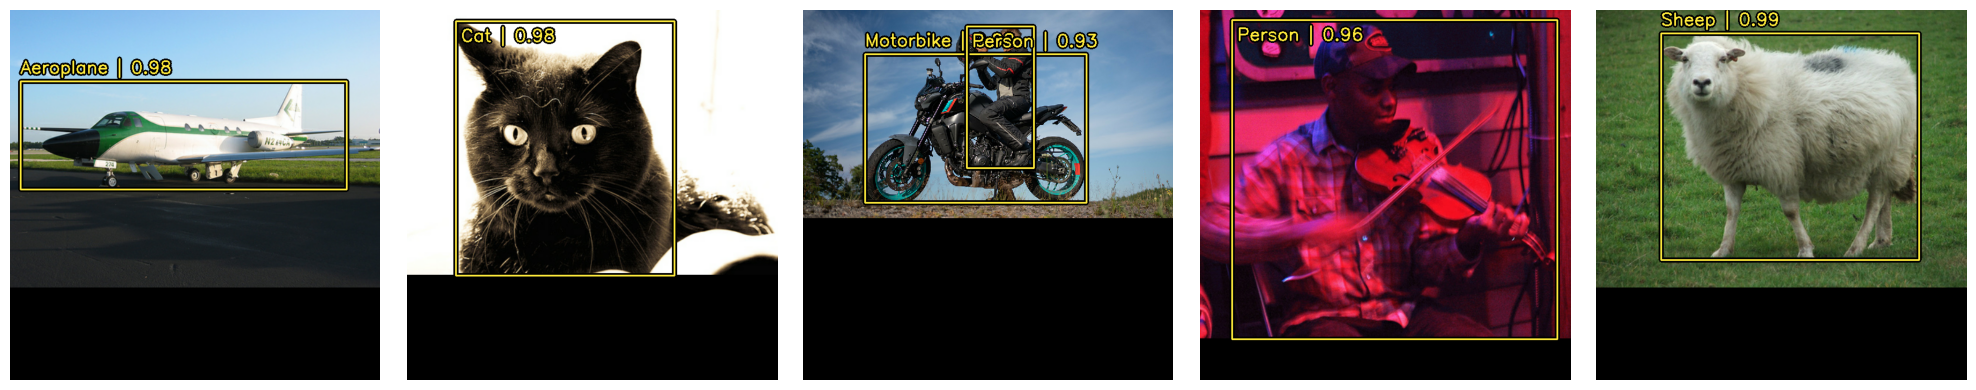

In [40]:
def detector(image_paths):
    all_processed_images = []
    file_names = []

    print(f"{'Image File':<15} | {'Detections (Label: Confidence)'}")
    print("-" * 70)

    # معالجة الصور وجمعها
    for path in image_paths[:5]:
        img_raw = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img_raw, channels=3)

        img_resized = inference_resizing(tf.expand_dims(img, axis=0))
        all_processed_images.append(img_resized)
        file_names.append(os.path.basename(path))

    full_batch = tf.concat(all_processed_images, axis=0)
    outputs = model.predict(full_batch)

    for i in range(len(file_names)):
        confidences = outputs['confidence'][i]
        classes = outputs['classes'][i]
        mask = confidences > 0.4
        detected_labels = [f"{class_ids[int(c)]}: {s:.2f}" for c, s in zip(classes[mask], confidences[mask])]
        print(f"{file_names[i]:<15} | {', '.join(detected_labels) if detected_labels else 'No objects detected'}")

    plt.figure(figsize=(25, 5))
    keras_cv.visualization.plot_bounding_box_gallery(
        full_batch,
        value_range=(0, 255),
        rows=1,
        cols=5,
        y_true=None,
        y_pred=outputs,
        scale=4,
        bounding_box_format="xywh",
        class_mapping={i: name for i, name in enumerate(class_ids)}
    )
    plt.show()

# القائمة الخاصة بك
image_list = [
    '/content/Images/Aeroplane.jpg',
    '/content/Images/Cat.jpg',
    '/content/Images/Motorbike.jpg',
    '/content/Images/Person.jpg',
    '/content/Images/Sheep.jpg'
]

detector(image_list)

6. Record for each image:

**Which objects were detected correctly:**
    All objects were detected correctly.

**The confidence scores of the detections: <br>**
   Aeroplane.jpg   | Aeroplane: 0.98  <br>
   Cat.jpg         | Cat: 0.98  <br>
   Motorbike.jpg   | Motorbike: 0.98, Person: 0.93 <br>  
   Person.jpg      | Person: 0.96 <br>
   Sheep.jpg       | Sheep: 0.99  

**Any missed or incorrectly labeled objects:**
     No All labels were detected correctly
    
